# Posterior Soay Sheep IPMs

Construct one GLM IPM and one GP IPM for every posterior draw, then save population growth, stable size distributions, reproductive values, and reproductive stable-size distributions.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import gpflow
from scipy.special import expit
from gpflow.conditionals.util import base_conditional_with_lm
from ipm_utils import calculate_ipm_metrics, make_gp_ipm, mk_K_glm, predict_y_mean, reproduction_fn_glm

/opt/anaconda3/envs/gpflow-env/lib/python3.11/site-packages/gpflow/versions.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [28]:
data = pd.read_csv("gp_ibm_dataset.csv")
true_metrics = dict(np.load("true_gp_metrics.npz"))
data.describe().round(2)

,z,Surv,z1,Repr,Sex,Recr,Rcsz,yr
count,760.00,760.00,525.00,525.00,313.00,154.0,139.00,760.00
mean,2.79,0.69,3.01,0.60,0.49,0.9,2.44,2.28
std,0.28,0.46,0.16,0.49,0.50,0.3,0.23,1.12
min,1.82,0.00,2.52,0.00,0.00,0.0,1.82,1.00
25%,2.61,0.00,2.91,0.00,0.00,1.0,2.29,1.00
50%,2.81,1.00,3.02,1.00,0.00,1.0,2.48,2.00
75%,3.00,1.00,3.13,1.00,1.00,1.0,2.61,3.00
max,3.35,1.00,3.35,1.00,1.00,1.0,2.95,4.00


In [ ]:
with np.load("gpdf_glm_samples.npz") as saved:
    glm_samples = {name: saved[name] for name in saved.files}
with np.load("gpdf_gp_samples.npz") as saved:
    gp_samples = {name: saved[name] for name in saved.files}

In [29]:
X_surv = data[["z"]].to_numpy(np.float64)
X_repr = data[["z", "Repr"]].dropna()[["z"]].to_numpy(np.float64)
X_growth = data[["z", "z1"]].dropna()[["z"]].to_numpy(np.float64)
X_rcsz = data[["z", "Rcsz"]].dropna()[["z"]].to_numpy(np.float64)
L, U, n_mesh = 1.7, 3.4, 250

In [30]:
n = 300

def draw(samples, index):
    return {name: value[index] for name, value in samples.items()}

def allocate(n):
    return {"lambda": np.empty(n), 
            "omega": np.empty((n, n_mesh)), 
            "omega_rep": np.empty((n, n_mesh)), 
            "gamma": np.empty((n, n_mesh))}

def store(target, index, metrics):
    for name in target:
        target[name][index] = metrics[name]

n_glm = min(value.shape[0] for value in glm_samples.values())
glm_metrics = allocate(n)
for i in range(n):
    params = draw(glm_samples, i) | {"female_prob": 0.5}
    ipm = mk_K_glm(n_mesh, params, L, U, correction=True)
    pb = reproduction_fn_glm(ipm["mesh_points"], params)
    store(glm_metrics, i, calculate_ipm_metrics(ipm["K"], pb))
    if i % 100 == 0:
        print(f"GLM Draw: {i}/{n}")

GLM Draw: 0/300
GLM Draw: 100/300
GLM Draw: 200/300


In [31]:
class MCMCConditionedGP:
    def __init__(self, x_train, mu_train, variance, lengthscale, intercept, likelihood, jitter=5e-4):
        dtype = gpflow.default_float()
        self.x_train = tf.convert_to_tensor(x_train, dtype=dtype)
        self.intercept = tf.convert_to_tensor(intercept, dtype=dtype)
        self.likelihood = likelihood
        centered = np.asarray(mu_train, dtype=np.float64).reshape(-1, 1) - float(intercept)
        self.f_train_centered = tf.convert_to_tensor(centered, dtype=dtype)
        self.kernel = gpflow.kernels.SquaredExponential(variance=float(variance), lengthscales=float(lengthscale))
        n = int(self.x_train.shape[0])
        covariance = self.kernel(self.x_train, self.x_train) + tf.cast(jitter, dtype) * tf.eye(n, dtype=dtype)
        self.cholesky = tf.linalg.cholesky(covariance)

    def _x(self, x):
        return tf.reshape(tf.convert_to_tensor(x, dtype=gpflow.default_float()), (-1, 1))

    def predict_f(self, x, full_cov=False, full_output_cov=False):
        x = self._x(x)
        cross_covariance = self.kernel(self.x_train, x)
        new_covariance = self.kernel(x, x) if full_cov else self.kernel.K_diag(x)
        mean, variance = base_conditional_with_lm(cross_covariance, self.cholesky, new_covariance, self.f_train_centered, full_cov=full_cov, white=False)
        return mean + self.intercept, variance

    def predict_y(self, x, full_cov=False, full_output_cov=False):
        x = self._x(x)
        mean, variance = self.predict_f(x)
        return self.likelihood.predict_mean_and_var(x, mean, variance)

def make_model(rate, x_train, params, likelihood):
    return MCMCConditionedGP(x_train, params[f"{rate}_mu"], params[f"{rate}_var"], params[f"{rate}_ls"], params[f"{rate}_int"], likelihood)

In [32]:
training_inputs = {"surv": X_surv, "repr": X_repr, "growth": X_growth, "rcsz": X_rcsz}

for rate, x_train in training_inputs.items():
    if x_train.shape[0] != gp_samples[f"{rate}_mu"].shape[1]:
        raise ValueError(f"{rate} training data do not match stored latent-function draws")

n_gp = min(value.shape[0] for value in gp_samples.values())

gp_metrics = allocate(n)
for i in range(n):
    params = draw(gp_samples, i) | {"female_prob": 0.5}
    funcs = {
        "surv": make_model("surv", X_surv, params, gpflow.likelihoods.Bernoulli(invlink=tf.sigmoid)),
        "repr": make_model("repr", X_repr, params, gpflow.likelihoods.Bernoulli(invlink=tf.sigmoid)),
        "growth": make_model("growth", X_growth, params, gpflow.likelihoods.Gaussian(variance=float(params["growth_noise"]) ** 2)),
        "rcsz": make_model("rcsz", X_rcsz, params, gpflow.likelihoods.Gaussian(variance=float(params["rcsz_noise"]) ** 2)),
    }
    ipm = make_gp_ipm(n_mesh, L, U, params, funcs, correction=True)
    pb = predict_y_mean(funcs["repr"], ipm["mesh_points"])
    store(gp_metrics, i, calculate_ipm_metrics(ipm["K"], pb))
    if i % 100 == 0:
        print(f"GP Draw: {i}/{n}")

GP Draw: 0/300
GP Draw: 100/300
GP Draw: 200/300


In [36]:
import matplotlib.pyplot as plt

def evaluate_ipm_models(model_samples, true_metrics, plot=False, epsilon=1e-12):
    def normalise(x):
        x = np.clip(np.asarray(x), epsilon, None)
        return x / x.sum(axis=-1, keepdims=True)

    true_lambda = float(true_metrics["lambda"])
    true_omega = normalise(true_metrics["omega"])
    true_gamma = np.asarray(true_metrics["gamma"])
    true_omega_rep = normalise(true_metrics["omega_rep"])
    scores = {}

    for model, samples in model_samples.items():
        lambdas = np.asarray(samples["lambda"])
        omegas = normalise(samples["omega"])
        gammas = np.asarray(samples["gamma"])
        omega_reps = normalise(samples["omega_rep"])

        lambda_mse = (lambdas - true_lambda) ** 2
        omega_kl = np.sum(true_omega * np.log(true_omega / omegas), axis=1)
        gamma_cosine = np.sum(gammas * true_gamma, axis=1) / (np.linalg.norm(gammas, axis=1) * np.linalg.norm(true_gamma))
        omega_rep_kl = np.sum(true_omega_rep * np.log(true_omega_rep / omega_reps), axis=1)

        scores[model] = {"Lambda MSE": lambda_mse, "Stable State KL": omega_kl, "Reproductive Value Cosine Similarity": gamma_cosine, "Reproductive Stable Distribution KL": omega_rep_kl}

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        for model, colour in zip(scores, ["tab:blue", "tab:orange"]):
            pd.Series(scores[model]["Stable State KL"]).plot.density(ax=axes[0], label=model, color=colour)
            pd.Series(scores[model]["Reproductive Value Cosine Similarity"]).plot.density(ax=axes[1], label=model, color=colour)
            pd.Series(scores[model]["Reproductive Stable Distribution KL"]).plot.density(ax=axes[2], label=model, color=colour)

        axes[0].set_title("Stable State KL")
        axes[0].set_xlabel("KL Divergence")

        axes[1].set_title("Reproductive Value")
        axes[1].set_xlabel("Cosine Similarity")
        #axes[1].set_xlim(left=0.7)
        #axes[1].set_xlim(right=1.05)

        axes[2].set_title("Reproductive Stable State KL")
        axes[2].set_xlabel("KL Divergence")

        for ax in axes:
            ax.set_ylabel("Density")
            ax.legend()

        plt.tight_layout()
        plt.show()

    return pd.DataFrame({model: {metric: np.mean(values) for metric, values in model_scores.items()} for model, model_scores in scores.items()}).T

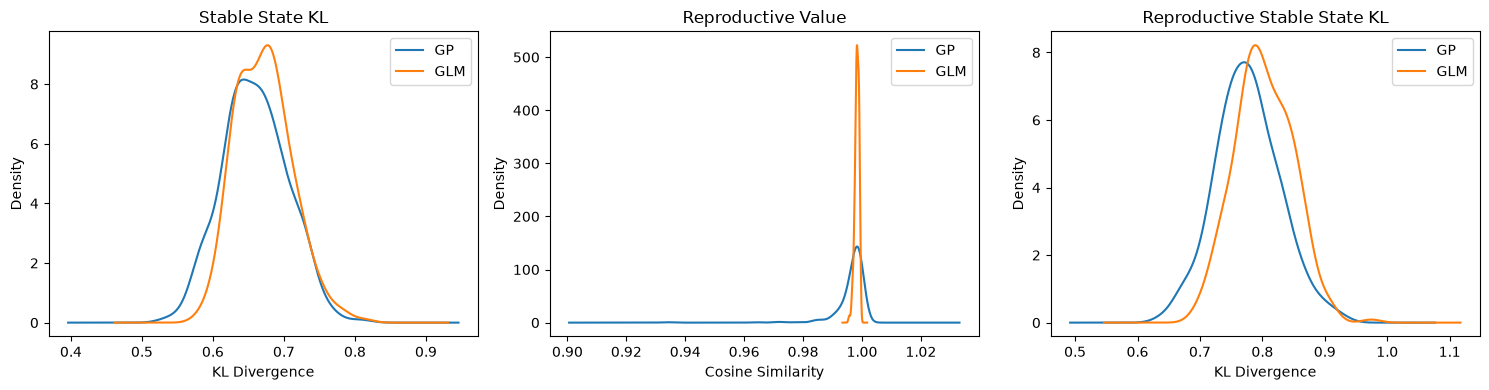

,Lambda MSE,Stable State KL,Reproductive Value Cosine Similarity,Reproductive Stable Distribution KL
GP,0.000636,0.659167,0.996408,0.776347
GLM,0.000767,0.671708,0.998290,0.802402


In [37]:
all_samples = {"GP": gp_metrics, "GLM": glm_metrics}
results_table = evaluate_ipm_models(all_samples, true_metrics, plot=True)
display(results_table)

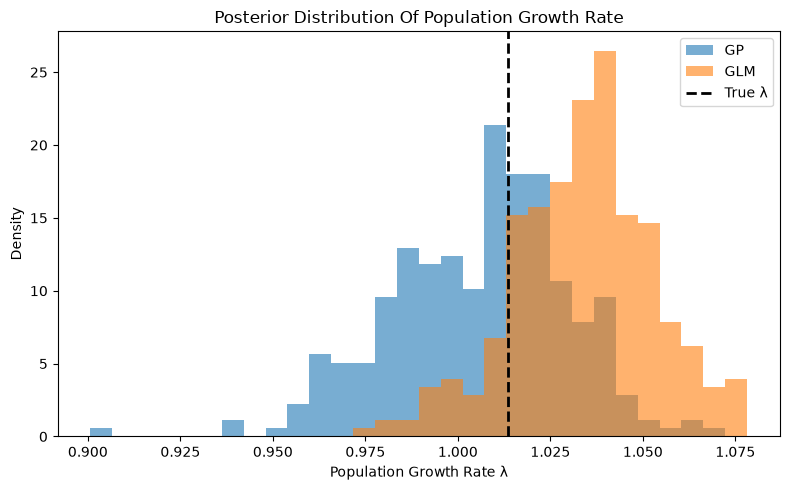

In [35]:
all_values = np.concatenate([gp_metrics["lambda"], glm_metrics["lambda"]])
bins = np.linspace(all_values.min(), all_values.max(), 31)

plt.figure(figsize=(8, 5))
plt.hist(gp_metrics["lambda"], bins=bins, density=True, alpha=0.6, label="GP")
plt.hist(glm_metrics["lambda"], bins=bins, density=True, alpha=0.6, label="GLM")
plt.axvline(float(true_metrics["lambda"]), color="black", linestyle="--", linewidth=2, label="True λ")
plt.xlabel("Population Growth Rate λ")
plt.ylabel("Density")
plt.title("Posterior Distribution Of Population Growth Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
np.savez_compressed("posterior_ipm_metrics.npz", glm_lambda=glm_metrics["lambda"], glm_omega=glm_metrics["omega"], glm_omega_rep=glm_metrics["omega_rep"], glm_gamma=glm_metrics["gamma"], gp_lambda=gp_metrics["lambda"], gp_omega=gp_metrics["omega"], gp_omega_rep=gp_metrics["omega_rep"], gp_gamma=gp_metrics["gamma"])
summary = pd.DataFrame({"GLM Mean": [glm_metrics["lambda"].mean()], "GLM SD": [glm_metrics["lambda"].std()], "GP Mean": [gp_metrics["lambda"].mean()], "GP SD": [gp_metrics["lambda"].std()], "True": [float(true_metrics["lambda"])]}, index=["Population Growth Rate"])
summary